<a href="https://colab.research.google.com/github/braulioalda4-code/Modelos_de_aprendizaje/blob/main/Practica2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
# Importa NumPy para realizar operaciones numéricas
import numpy as np
# Importa Pandas para trabajar con tablas y estructuras de datos
import pandas as pd
# Importa Matplotlib para generar visualizaciones
import matplotlib.pyplot as plt
# Importa la función que proporciona el conjunto de datos Diabetes
from sklearn.datasets import load_diabetes

In [30]:
# Carga el conjunto de datos Diabetes
data = load_diabetes()

In [31]:
# Obtiene las variables predictoras
X = data.data

In [32]:
# Obtiene la variable que representa la progresión de la diabetes
y = data.target

In [33]:
# Muestra el número de observaciones y variables
print("Dimensiones de X:", X.shape)

Dimensiones de X: (442, 10)


In [34]:
# Muestra el número de valores objetivo
print("Dimensiones de y:", y.shape)

Dimensiones de y: (442,)


In [35]:
# Crea un DataFrame utilizando características del conjunto de datos
df = pd.DataFrame(
    X,
    columns=data.feature_names
)

In [36]:
# Agrega la variable objetivo como una nueva columna
df["target"] = y

In [37]:
# Muestra los primeros cinco registros
print(df.head())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


In [38]:
# Muestra información sobre las columnas y tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [39]:
# Calcula estadísticas descriptivas de las variables
print(df.describe())

                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 -1.267807e-01   
25%   -3.729927e-02 -4.464164e-02 -3.422907e-02 -3.665608e-02 -3.424784e-02   
50%    5.383060e-03 -4.464164e-02 -7.283766e-03 -5.670422e-03 -4.320866e-03   
75%    3.807591e-02  5.068012e-02  3.124802e-02  3.564379e-02  2.835801e-02   
max    1.107267e-01  5.068012e-02  1.705552e-01  1.320436e-01  1.539137e-01   

                 s2            s3            s4            s5            s6  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean   3.918434e-17 -5.777179e-18 -9.042540e-18  9.293722e-17  1.130318e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.

In [40]:
# Cuenta los valores faltantes de cada columna
print(df.isnull().sum())

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


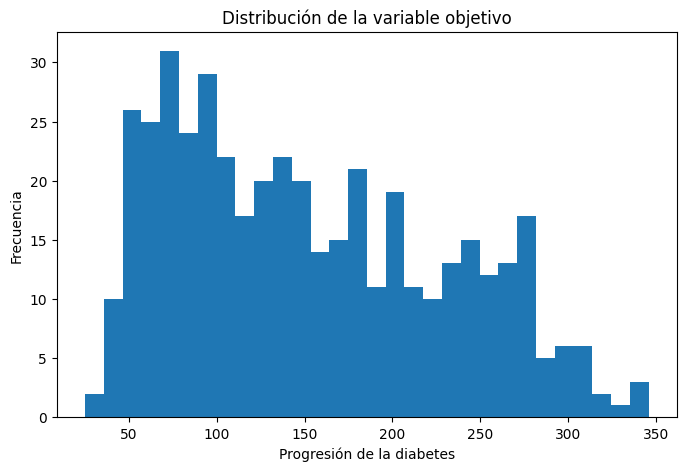

In [41]:
# Define el tamaño de la figura
plt.figure(figsize=(8,5))
# Genera un histograma de la variable objetivo
plt.hist(y, bins=30)
# Define el nombre del eje x
plt.xlabel("Progresión de la diabetes")
# Define el nombre del eje y
plt.ylabel("Frecuencia")
# Agrega un título
plt.title("Distribución de la variable objetivo")
# Muestra la gráfica
plt.show()

In [42]:
# Importa la función para dividir los datos
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,              # Variables predictoras
    y,              # Variable objetivo
    test_size=0.2,  # Reserva el 20 % para evaluación
    random_state=42 # Permite reproducir la división
)

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [44]:
# Importa el modelo de regresión lineal
from sklearn.linear_model import LinearRegression

In [45]:
# Crea una instancia de regresión lineal sin regularización
modelo_lineal = LinearRegression()
# Entrena el modelo utilizando los datos estandirizados
modelo_lineal.fit(
    X_train_scaled,
    y_train
)
# Genera predicciones para los datos prueba
pred_lineal = modelo_lineal.predict(
    X_test_scaled)


In [46]:
# Importa métricas para evaluar modelos de regresion
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [47]:
# Calcula el error absoluto medio
mae_lineal = mean_absolute_error(
    y_test,
    pred_lineal
)
# Calcula el error cuadrático medio
rmse_lineal = np.sqrt(
    mean_squared_error(
        y_test,
        pred_lineal
    )
)
# Calcula el coeficiente de determinación
r2_lineal = r2_score(
    y_test,
    pred_lineal
)

In [48]:
# Muestra las métricas obtenidas por la regresión lineal
print("\n--- Regresión Lineal ---")
print("MAE :", mae_lineal)
print("RMSE:", rmse_lineal)
print("R²  :", r2_lineal)


--- Regresión Lineal ---
MAE : 42.79409467959994
RMSE: 53.853445836765935
R²  : 0.45260276297191926


In [49]:
# Crea una tabla con el nombre de cada variable y su coeficiente
coef_lineal = pd.DataFrame(
    {"Variable": data.feature_names,
     "Coeficiente": modelo_lineal.coef_
})

# Muestra la tabla ordenada por el valor absoluto del coeficiente
print(
     coef_lineal.reindex(
        coef_lineal["Coeficiente"].abs()
        .sort_values(ascending=False)
        .index
    )
)

  Variable  Coeficiente
4       s1   -44.448856
8       s5    35.161195
2      bmi    25.607121
5       s2    24.640954
3       bp    16.828872
7       s4    13.138784
1      sex   -11.511809
6       s3     7.676978
9       s6     2.351364
0      age     1.753758


In [50]:
# Importa el algoritmo Ridge, que utiliza regularización L2
from sklearn.linear_model import Ridge

In [51]:
# Crea un modelo Ridge con alpha igual a 1
modelo_ridge = Ridge(
    alpha=1.0
)
# Entrena el modelo Ridge con los datos de entrenamiento.
modelo_ridge.fit(
    X_train_scaled,
    y_train
)
# Genera predicciones para el conjunto de pruba
pred_ridge = modelo_ridge.predict(
    X_test_scaled
)
# Calcula el MAE del modelo Ridge
mae_ridge = mean_absolute_error(
    y_test, pred_ridge
)
# Calcula el RMSE del modelo Ridge
rmse_ridge = np.sqrt(
    mean_squared_error(
        y_test,
        pred_ridge
    )
)
# Calcula el R2 del modelo Ridge
r2_ridge = r2_score(
    y_test,
    pred_ridge
)

In [52]:
# Muestra las métricas del modelo Ridge
print("\n--- Ridge (L2) ---")
print("MAE :", mae_ridge)
print("RMSE:", rmse_ridge)
print("R²  :", r2_ridge)


--- Ridge (L2) ---
MAE : 42.81199941834888
RMSE: 53.777454065343896
R²  : 0.45414652070698225


In [53]:
# Crea una tabla para comparar los coeficientes de Ridge
coef_ridge = pd.DataFrame({
    "Variable": data.feature_names,
    "Coeficiente": modelo_ridge.coef_
})
# Muestra los coeficientes
print (coef_ridge)

  Variable  Coeficiente
0      age     1.807342
1      sex   -11.448190
2      bmi    25.732699
3       bp    16.734300
4       s1   -34.671954
5       s2    17.053075
6       s3     3.369914
7       s4    11.764260
8       s5    31.378384
9       s6     2.458139


In [54]:
# Importa el algoritmo Lasso, que utiliza regularizacion L1
from sklearn.linear_model import Lasso

In [55]:
# Crea un modelo Lasso con alpha igual a 0.1
modelo_lasso = Lasso(
    alpha=0.1
)
#Entrena el modelo Lasso
modelo_lasso.fit(
    X_train_scaled,
    y_train
)
pred_lasso = modelo_lasso.predict(
    X_test_scaled
)

In [56]:
# Calcula el MAE del modelo Lasso
mae_lasso = mean_absolute_error(
    y_test,
    pred_lasso
)
# Calcula el RMSE del modelo Lasso
rmse_lasso = np.sqrt(
    mean_squared_error(
        y_test,
        pred_lasso
    )
)
# Calcula el R2 del modelo Lasso
r2_lasso = r2_score(
    y_test,
    pred_lasso
)

In [57]:
# Muestra las métricas obtenidas por Lasso
print("\n--- Lasso (L1) ---")
print("MAE :", mae_lasso)
print("RMSE:", rmse_lasso)
print("R²  :", r2_lasso)


--- Lasso (L1) ---
MAE : 42.805234446768836
RMSE: 53.70869844573793
R²  : 0.45554139902790414


In [58]:
# Crea una tabla para comparar los tres modelos
resultados = pd.DataFrame(
    {
        "Modelo": [
            "Regresión lineal",
            "Ridge L2",
            "Lasso L1"
            ],

        "MAE": [mae_lineal,
                mae_ridge,
                mae_lasso
                ],
        "RMSE": [rmse_lineal,
                 rmse_ridge,
                 rmse_lasso
                 ],
        "R2": [r2_lineal,
               r2_ridge,
               r2_lasso
               ],
    }
)
# Muestra la tabla de resultados
print("\n--- Comparación de Modelos ---")
print(resultados)


--- Comparación de Modelos ---
             Modelo        MAE       RMSE        R2
0  Regresión lineal  42.794095  53.853446  0.452603
1          Ridge L2  42.811999  53.777454  0.454147
2          Lasso L1  42.805234  53.708698  0.455541


In [59]:
# Construye una tabla con los coeficientes de los tres modelos
coefientes = pd.DataFrame(
    {
        # Nombre de cada variable
        "Variable": data.feature_names,
        # Coeficientes del modelo sin regularización
        "Lineal": modelo_lineal.coef_,
        # Coeficientes obtenidos mediante Ridge
        "Ridge": modelo_ridge.coef_,
        # Coeficientes obtenidos mediante Lasso
        "Lasso": modelo_lasso.coef_,
    }
)
print("\n--- Comparación de Coeficientes ---")
# Muestra la tabla
print(coefientes)


--- Comparación de Coeficientes ---
  Variable     Lineal      Ridge      Lasso
0      age   1.753758   1.807342   1.730451
1      sex -11.511809 -11.448190 -11.316359
2      bmi  25.607121  25.732699  25.824627
3       bp  16.828872  16.734300  16.644252
4       s1 -44.448856 -34.671954 -29.358412
5       s2  24.640954  17.053075  13.275844
6       s3   7.676978   3.369914   0.547948
7       s4  13.138784  11.764260  10.236168
8       s5  35.161195  31.378384  29.632826
9       s6   2.351364   2.458139   2.393475


In [60]:
# Identifica qué coeficientes de Lasso son exactamente iguales a cero
coef_cero = np.isclose(
    modelo_lasso.coef_,
    0
)
# Muestra los nombres de las variables cuyos coeficientes fueron eliminados
print(
    "\nVariables eliminadas por Lasso:",
    np.array(data.feature_names)[coef_cero],
)


Variables eliminadas por Lasso: []


In [61]:
# Define la posición de cada variable en el eje X
posiciones = np.arange(
    len(data.feature_names)
)

In [62]:
# Define el ancho de cada grupo de barras
ancho = 0.25

In [63]:
# Crea una figura
plt.figure(figsize=(14, 6))

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

<BarContainer object of 10 artists>

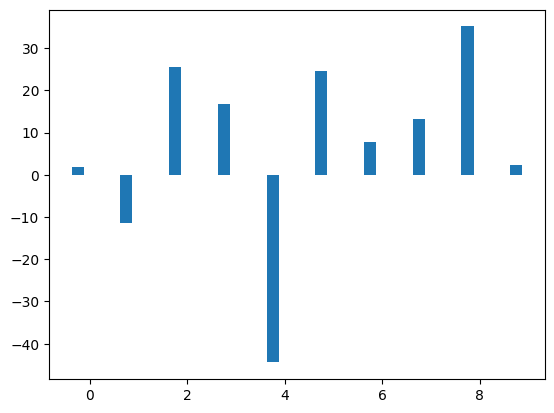

In [64]:
# Dibuja los coeficientes del modelo lineal
plt.bar(
    posiciones - ancho,
    modelo_lineal.coef_,
    width=ancho,
    label="Lineal",
)

<BarContainer object of 10 artists>

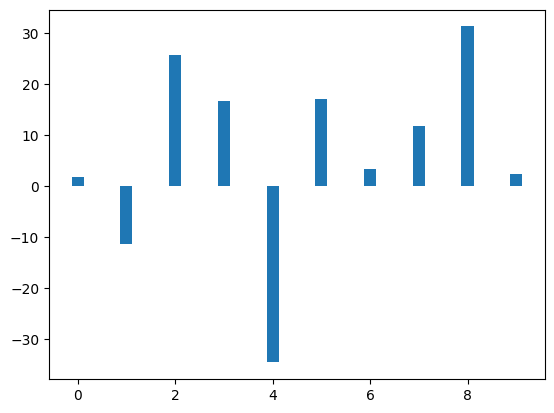

In [65]:
# Dibuja los coeficientes de Ridge
plt.bar(
    posiciones,
    modelo_ridge.coef_,
    width = ancho,
    label = "Ridge"
)

<BarContainer object of 10 artists>

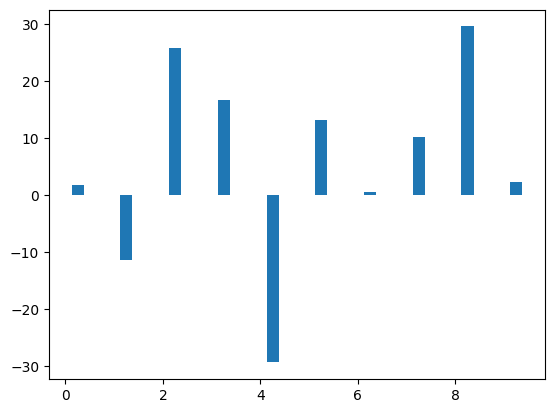

In [66]:
# Dibuja los coeficientes de Lasso
plt.bar(
    posiciones + ancho,
    modelo_lasso.coef_,
    width=ancho,
    label="Lasso",
)

/tmp/ipykernel_1380/2375048653.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


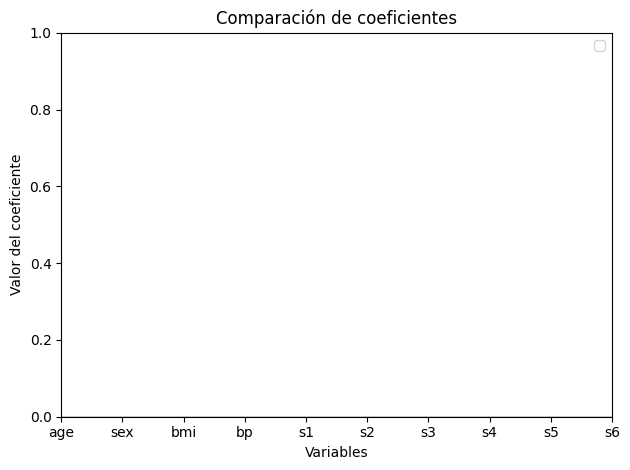

In [67]:
# Coloca los nombres de las variables en el eje x
plt.xticks(
    posiciones,
    data.feature_names
)
# Agrega una línea horizontal correspondiente a cero
plt.axhline(
    0,
    color="black",
    linewidth=1
)
# Etiqueta el eje X
plt.xlabel("Variables")
# Etiqueta el eje Y
plt.ylabel("Valor del coeficiente")
# Agrega un título
plt.title("Comparación de coeficientes")
# Muestra la leyenda
plt.legend()
# Ajusta automáticamente los elementos de la gráfica
plt.tight_layout()
# Muestra la gráfica
plt.show()

In [68]:
# Define diferentes intensidades de regularización
alphas = [
    0.001,
    0.01,
    0.1,
    1,
    10,
    100,
]

In [69]:
# Crea una lista vacía para almacenar el RMSE
rmse_ridge_list = []

In [70]:
# Crea una lsita vacía para almacenar el RMSE de Lasso
rmse_lasso_list = []

In [71]:
# Crea una lista vacía para almacenar el número de coeficientes
# diferentes de cero en Lasso
coeficientes_lasso = []

In [72]:
# Recorre todos los valores de alpha
for alpha in alphas:

  # Crea un nuevo modelo Ridge utilizando el alpha actual
  ridge = Ridge(
      alpha = alpha
  )

  # Entrena el modelo Ridge
  ridge.fit(
      X_train_scaled,
      y_train
  )

  # Genera predicciones
  pred_ridge = ridge.predict(
      X_test_scaled
      )

  # Calcula y almacena el RMSE
  rmse_ridge_list.append(
      np.sqrt(
          mean_squared_error(
              y_test,
              pred_ridge
          )
      )
  )

  # Crea un nuevo modelo Lasso
  lasso = Lasso(
    alpha = alpha,
    max_iter = 10000
  )

  # Entrena el modelo Lasso
  lasso.fit(
    X_train_scaled,
    y_train
  )

  # Genera predicciones
  pred_lasso = lasso.predict(
    X_test_scaled
  )

  # Calcula y almacena el RMSE
  rmse_lasso_list.append(
      np.sqrt(
          mean_squared_error(
              y_test,
              pred_lasso
          )
      )
  )

  # Cuenta cuántos coeficientes de Lasso son diferentes de cero
  cantidad = np.sum(
      np.abs(lasso.coef_) > 1e-6
  )

  # Guarda la cantidad de coeficientes activos
  coeficientes_lasso.append(cantidad)

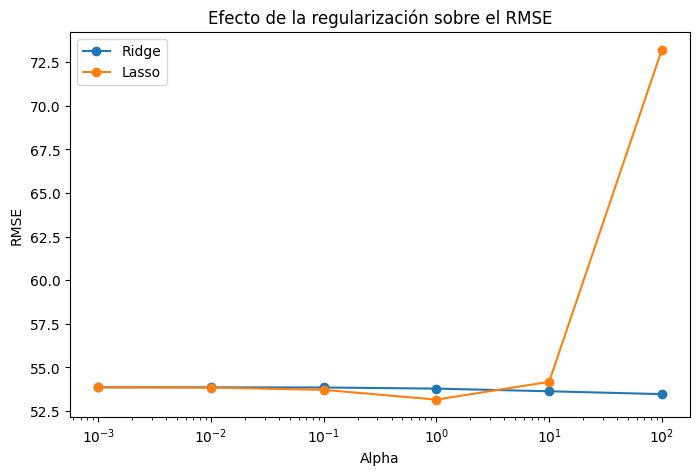

In [73]:
# Crea una figura
plt.figure(figsize=(8, 5))

# Grafica el RMSE de Ridge para cada valor de alpha
plt.semilogx(
    alphas,
    rmse_ridge_list,
    marker="o",
    label="Ridge"
)

# Grafica el RMSE de Lasso
plt.semilogx(
    alphas,
    rmse_lasso_list,
    marker="o",
    label="Lasso"
)

# Etiqueta el eje X
plt.xlabel("Alpha")

# Etiqueta el eje Y
plt.ylabel("RMSE")

# Agrega un título
plt.title("Efecto de la regularización sobre el RMSE")

# Muestra la leyenda
plt.legend()

# Muestra la gráfica
plt.show()

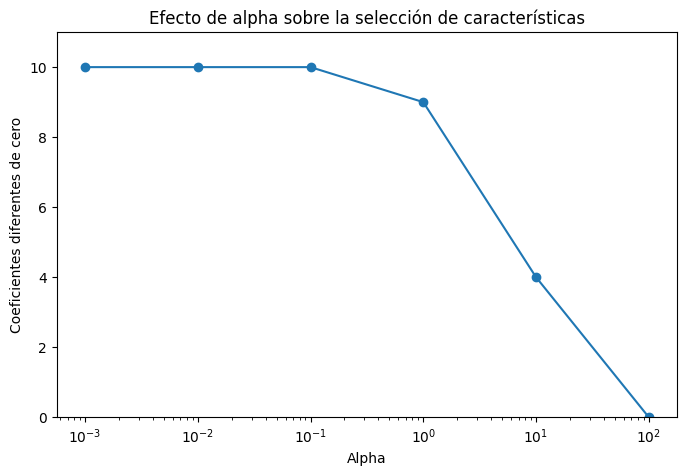

In [74]:
# Crea una figura
plt.figure(figsize=(8, 5))

# Grafica el número de coeficientes activos para cada alpha
plt.semilogx(
    alphas,
    coeficientes_lasso,
    marker="o"
)

# Etiqueta el eje x
plt.xlabel("Alpha")

# Etiqueta el eje y
plt.ylabel("Coeficientes diferentes de cero")

# Agrega un título
plt.title("Efecto de alpha sobre la selección de características")

# Define el número máximo posible de características
plt.ylim(
    0,
    len(data.feature_names) + 1
)

# Muestra la gráfica
plt.show()
